## Trader Behavior vs Market Sentiment Analysis

#### Objective

##### Financial markets are often influenced by investor sentiment, which reflects the overall mood of market participants. Periods of Fear typically indicate pessimism and market uncertainty, while periods of Greed indicate optimism and increased risk-taking.

##### This project analyzes how market sentiment influences trader behavior and trading performance using historical trading data and a market sentiment index.

##### By combining these two datasets, we aim to understand whether traders behave differently during Fear and Greed market conditions, and whether certain trading patterns lead to better performance.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#### Load the Datasets

In this step, we load the two datasets required for the analysis.

Trader Historical Data – Contains detailed information about each trade executed by traders, including trade size, profit/loss, and timestamp.

Market Sentiment Data – Contains daily market sentiment indicators such as Fear, Greed, Extreme Fear, and Extreme Greed.

These datasets will later be combined to analyze how market sentiment influences trader behavior and performance.

In [9]:
# Dataset

sentiment = pd.read_csv(r"D:\Kaushal\Internship test\Company 1\fear_greed_index.csv")
history = pd.read_csv(r"D:\Kaushal\Internship test\Company 1\historical_data.csv")

In [10]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [17]:
sentiment.shape

(2644, 4)

In [19]:
history.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [21]:
history.shape

(211224, 16)

### Initial Data Exploration

Before performing any analysis, it is important to understand the structure and characteristics of the datasets.

In this step we will:

Inspect the data types of each column

Identify missing values

Understand the basic statistics of the numerical variables

Explore the structure of the datasets

This helps ensure that the data is clean and ready for further analysis.

In [28]:
history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [30]:
history.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [32]:
history.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [34]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [36]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [40]:
sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


#### Data Cleaning and Preparation

Before combining the datasets, we need to ensure that the data formats are consistent and suitable for analysis.

In this step we will:

Convert timestamp columns to datetime format

Create a date column from the timestamp

Prepare the sentiment dataset
Ensure both datasets can be merged using the date column

This preparation ensures that each trade can be matched with the market sentiment of the same day.

In [43]:
history['Timestamp IST'] = pd.to_datetime(history['Timestamp IST'], dayfirst=True)

In [45]:
history['date'] = history['Timestamp IST'].dt.date
history['date'] = pd.to_datetime(history['date'])

In [57]:
history[['Timestamp IST','date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [49]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [55]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


#### Merge Trader Data with Sentiment Data

To analyze how market sentiment affects trader behavior, we combine the trader dataset with the sentiment dataset.

Both datasets contain a date column, which allows us to merge them so that each trade is associated with the market sentiment on the same day.

This merged dataset will allow us to analyze:

trader performance under different sentiment conditions

behavioral changes based on sentiment

trading patterns during Fear and Greed periods

In [62]:
data = history.merge(sentiment, on='date', how='left')

In [64]:
data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [68]:
data[['date','Account','Closed PnL','classification']].head()

,date,Account,Closed PnL,classification
0,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,Extreme Greed
1,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,Extreme Greed
2,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,Extreme Greed
3,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,Extreme Greed
4,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,Extreme Greed


In [70]:
data['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

#### Sentiment Grouping

The sentiment dataset contains several categories such as Extreme Fear, Fear, Neutral, Greed, and Extreme Greed.

To simplify the analysis and focus on broader market regimes, we group the extreme categories into their corresponding sentiment groups:

Extreme Fear → Fear

Extreme Greed → Greed

This allows us to compare trader behavior between Fear, Greed, and Neutral market conditions.

In [73]:
data['sentiment_group'] = data['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

In [75]:
data['sentiment_group'].value_counts()

sentiment_group
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64

In [77]:
data[['date','Account','Closed PnL','sentiment_group']].head()

,date,Account,Closed PnL,sentiment_group
0,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,Greed
1,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,Greed
2,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,Greed
3,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,Greed
4,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.0,Greed


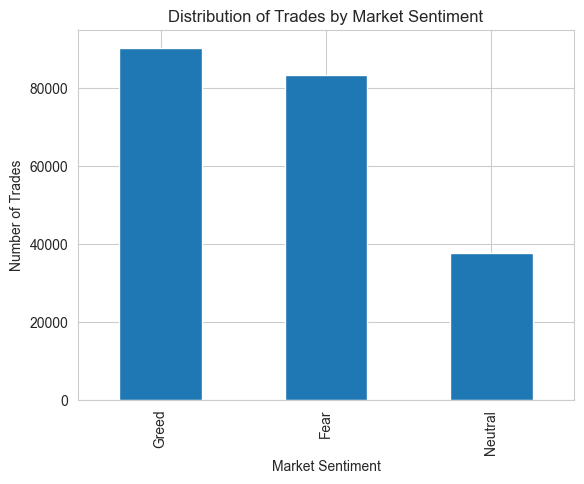

In [82]:
data['sentiment_group'].value_counts().plot(kind='bar')

plt.title("Distribution of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

#### Key Metrics 

Before performing deeper analysis, we create several key metrics that help
measure trader performance and behavior.

These metrics include:

- Daily PnL per trader
- Win rate
- Average trade size
- Number of trades per day
- Long/Short trade ratio

##### Daily PnL per Trader

In [129]:
trader_day = data.groupby(['Account','date']).agg({
    'Closed PnL':'sum',
    'Size USD':'mean',
    'Account':'count'
}).rename(columns={
    'Closed PnL':'daily_pnl',
    'Size USD':'avg_trade_size',
    'Account':'trades_per_day'
}).reset_index()

##### Win Rate

In [138]:
data['win'] = data['Closed PnL'] > 0

In [140]:
data.groupby('sentiment_group')['win'].mean()

sentiment_group
Fear       0.407871
Greed      0.420311
Neutral    0.396991
Name: win, dtype: float64

##### Number of Trades Per Day

In [149]:
data.groupby('date')['Account'].count().head(10)

date
2023-05-01     3
2023-12-05     9
2023-12-14    11
2023-12-15     2
2023-12-16     3
2023-12-17    14
2023-12-18     2
2023-12-19    15
2023-12-20    18
2023-12-21    49
Name: Account, dtype: int64

##### Long / Short Ratio

In [152]:
data['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [154]:
data.groupby('sentiment_group')['Direction'].value_counts()

sentiment_group  Direction                
Fear             Open Long                    24829
                 Close Long                   23501
                 Open Short                   14061
                 Close Short                  12338
                 Sell                          4406
                 Buy                           4014
                 Spot Dust Conversion            45
                 Short > Long                    24
                 Long > Short                    19
Greed            Open Short                   19327
                 Close Short                  17819
                 Close Long                   15184
                 Open Long                    14844
                 Sell                         13150
                 Buy                           9817
                 Spot Dust Conversion            87
                 Short > Long                    34
                 Long > Short                    23
                 Auto

##### Average Trade Size

In [156]:
data.groupby('sentiment_group')['Size USD'].mean()

sentiment_group
Fear       7182.011019
Greed      4574.424490
Neutral    4782.732661
Name: Size USD, dtype: float64

#### Performance Analysis by Sentiment

We evaluate trader performance using the following metrics:

- Average profit per trade
- Total profit
- Win rate

This helps determine whether traders perform better during Fear or Greed periods.

#### Average Profit

In [85]:
data.groupby('sentiment_group')['Closed PnL'].mean()

sentiment_group
Fear       49.212077
Greed      53.882281
Neutral    34.307718
Name: Closed PnL, dtype: float64

In [161]:
# Total Profit

data.groupby('sentiment_group')['Closed PnL'].sum()

sentiment_group
Fear       4.096266e+06
Greed      4.865301e+06
Neutral    1.292921e+06
Name: Closed PnL, dtype: float64

In [165]:
# Win Rate Comparison

data.groupby('sentiment_group')['win'].mean()

sentiment_group
Fear       0.407871
Greed      0.420311
Neutral    0.396991
Name: win, dtype: float64

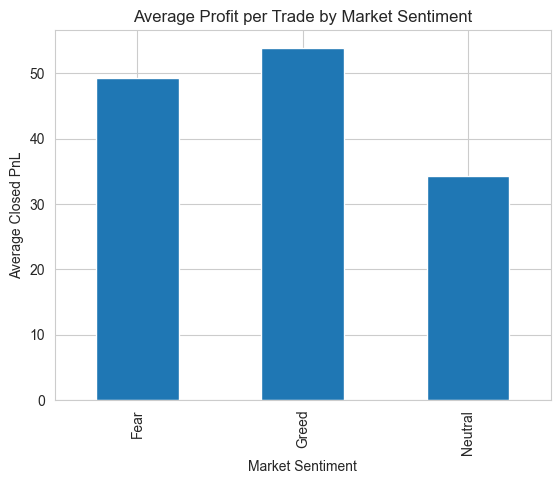

In [163]:
data.groupby('sentiment_group')['Closed PnL'].mean().plot(kind='bar')

plt.title("Average Profit per Trade by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

#### Trader Behavior Analysis

In this step we analyze how trader behavior changes based on market sentiment.

Behavior is measured using:

- Trade size
- Trading frequency
- Long vs Short trade preference

##### Trade Size

In [203]:
data.groupby('sentiment_group')['Size USD'].mean()

sentiment_group
Fear       7182.011019
Greed      4574.424490
Neutral    4782.732661
Name: Size USD, dtype: float64

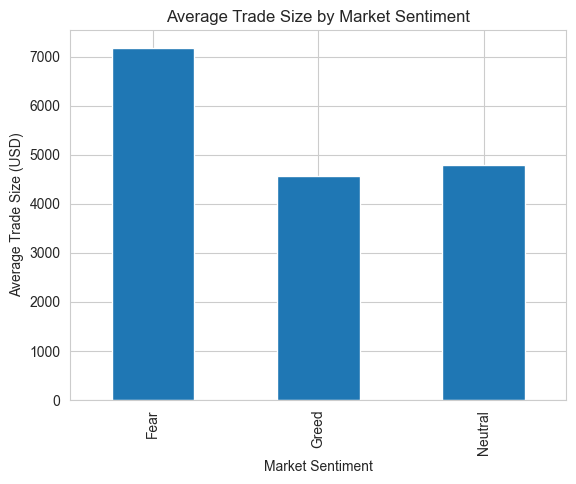

In [98]:
data.groupby('sentiment_group')['Size USD'].mean().plot(kind='bar')

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

##### Trade Frequency

In [206]:
data.groupby('sentiment_group')['Account'].count()

sentiment_group
Fear       83237
Greed      90295
Neutral    37686
Name: Account, dtype: int64

##### Long / Short Bias

In [211]:
data.groupby('sentiment_group')['Direction'].value_counts()

sentiment_group  Direction                
Fear             Open Long                    24829
                 Close Long                   23501
                 Open Short                   14061
                 Close Short                  12338
                 Sell                          4406
                 Buy                           4014
                 Spot Dust Conversion            45
                 Short > Long                    24
                 Long > Short                    19
Greed            Open Short                   19327
                 Close Short                  17819
                 Close Long                   15184
                 Open Long                    14844
                 Sell                         13150
                 Buy                           9817
                 Spot Dust Conversion            87
                 Short > Long                    34
                 Long > Short                    23
                 Auto

#### Trader Segmentation

To analyze differences between traders, we aggregate the dataset at the trader level.

This allows us to evaluate each trader based on:

Total Profit (total_pnl)

Average Trade Size (avg_trade_size)

Total Number of Trades (total_trades)

Using these metrics, traders can be segmented into groups based on their trading activity and capital deployment.

In [101]:
trader_summary = data.groupby('Account').agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'Account': 'count'
}).rename(columns={
    'Closed PnL': 'total_pnl',
    'Size USD': 'avg_trade_size',
    'Account': 'total_trades'
}).reset_index()

In [103]:
trader_summary.head()

,Account,total_pnl,avg_trade_size,total_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,16159.576734,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,1653.226327,7280
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,8893.000898,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,507.626933,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3138.894782,3239


In [107]:
trader_summary.describe()

,total_pnl,avg_trade_size,total_trades
count,3.200000e+01,32.000000,32.000000
mean,3.217800e+05,6007.929370,6600.750000
std,4.948276e+05,7281.058575,8250.373724
min,-1.676211e+05,507.626933,332.000000
25%,4.689324e+04,2011.069878,1381.750000
50%,1.176551e+05,3327.972048,3699.000000
75%,4.063941e+05,7375.525018,8862.500000
max,2.143383e+06,34396.580284,40184.000000


#### Segment 1 — Frequent vs Infrequent Traders

In [110]:
median_trades = trader_summary['total_trades'].median()

trader_summary['trader_activity'] = trader_summary['total_trades'].apply(
    lambda x: 'Frequent' if x > median_trades else 'Infrequent'
)

In [114]:
trader_summary['trader_activity'].value_counts()

trader_activity
Frequent      16
Infrequent    16
Name: count, dtype: int64

In [116]:
trader_summary.groupby('trader_activity')['total_pnl'].mean()

trader_activity
Frequent      496527.661215
Infrequent    147032.272750
Name: total_pnl, dtype: float64

#### Segment 2 — High vs Low Trade Size Traders

In [120]:
median_size = trader_summary['avg_trade_size'].median()

trader_summary['size_segment'] = trader_summary['avg_trade_size'].apply(
    lambda x: 'High Size Trader' if x > median_size else 'Low Size Trader'
)

In [122]:
trader_summary['size_segment'].value_counts()

size_segment
High Size Trader    16
Low Size Trader     16
Name: count, dtype: int64

In [124]:
trader_summary.groupby('size_segment')['total_pnl'].mean()

size_segment
High Size Trader    416805.966542
Low Size Trader     226753.967423
Name: total_pnl, dtype: float64

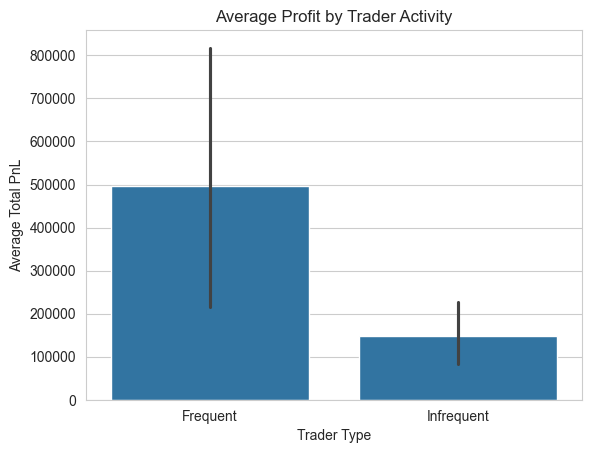

In [126]:
sns.barplot(x='trader_activity', y='total_pnl', data=trader_summary)

plt.title("Average Profit by Trader Activity")
plt.xlabel("Trader Type")
plt.ylabel("Average Total PnL")
plt.show()

#### Segment 3: Consistent vs Inconsistent Traders

In [220]:
trader_winrate = data.groupby('Account')['win'].mean().reset_index()

trader_winrate.rename(columns={'win':'win_rate'}, inplace=True)

In [222]:
trader_winrate.head()

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [224]:
trader_summary = trader_summary.merge(trader_winrate, on='Account')

In [226]:
median_winrate = trader_summary['win_rate'].median()

trader_summary['consistency_segment'] = trader_summary['win_rate'].apply(
    lambda x: 'Consistent Winner' if x > median_winrate else 'Inconsistent Trader'
)

In [228]:
trader_summary['consistency_segment'].value_counts()

consistency_segment
Inconsistent Trader    16
Consistent Winner      16
Name: count, dtype: int64

##### Compare Performance

In [233]:
trader_summary.groupby('consistency_segment')['total_pnl'].mean()

consistency_segment
Consistent Winner      296760.268498
Inconsistent Trader    346799.665467
Name: total_pnl, dtype: float64

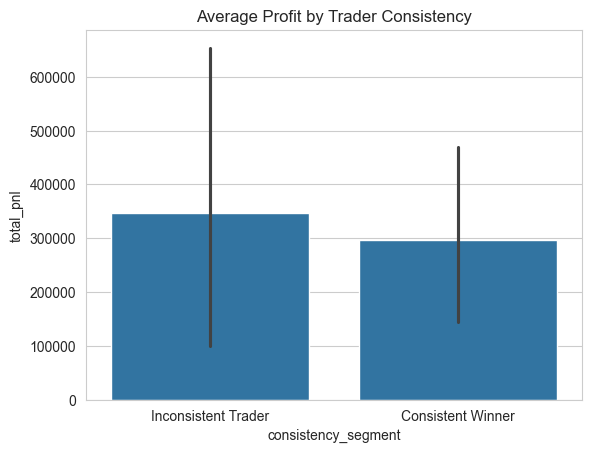

In [235]:
sns.barplot(
    x='consistency_segment',
    y='total_pnl',
    data=trader_summary
)

plt.title("Average Profit by Trader Consistency")
plt.show()

### Bonus - RandomForest model

In [266]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [ ]:
data['win'] = data['Closed PnL'] > 0

trader_day = data.groupby(['Account','date']).agg(
    daily_pnl=('Closed PnL','sum'),
    avg_trade_size=('Size USD','mean'),
    trades_per_day=('Account','count')
).reset_index()

daily_win = data.groupby(['Account','date'])['win'].mean().reset_index()

daily_win.rename(columns={'win':'win_rate'}, inplace=True)

trader_day = trader_day.merge(
    daily_win,
    on=['Account','date'],
    how='left'
)

In [277]:
sentiment_daily = data[['Account','date','sentiment_group']].drop_duplicates()

trader_day = trader_day.merge(
    sentiment_daily,
    on=['Account','date'],
    how='left'
)


trader_day = trader_day.sort_values(['Account','date'])

In [279]:
trader_day['prev_pnl'] = trader_day.groupby('Account')['daily_pnl'].shift(1)
trader_day['prev_trades'] = trader_day.groupby('Account')['trades_per_day'].shift(1)
trader_day['prev_win_rate'] = trader_day.groupby('Account')['win_rate'].shift(1)
trader_day['prev_size'] = trader_day.groupby('Account')['avg_trade_size'].shift(1)
trader_day['pnl_3d_avg'] = trader_day.groupby('Account')['daily_pnl'].rolling(3).mean().reset_index(0,drop=True)
trader_day['pnl_7d_avg'] = trader_day.groupby('Account')['daily_pnl'].rolling(7).mean().reset_index(0,drop=True)

In [281]:
le = LabelEncoder()
trader_day['sentiment_enc'] = le.fit_transform(trader_day['sentiment_group'])
trader_day['next_pnl'] = trader_day.groupby('Account')['daily_pnl'].shift(-1)

trader_day['target'] = pd.cut(
    trader_day['next_pnl'],
    bins=[-np.inf,0,np.inf],
    labels=['Loss','Profit']
)

In [283]:
# Feature selection
features = [
    'sentiment_enc',
    'prev_pnl',
    'prev_trades',
    'prev_win_rate',
    'prev_size',
    'pnl_3d_avg',
    'pnl_7d_avg'
]

model_df = trader_day[features + ['target']].dropna()

X = model_df[features]
y = model_df['target']


In [ ]:
# Check dataset balance

print("Dataset shape:", X.shape)

print("\nClass distribution:")
print(y.value_counts(normalize=True).round(3))

# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Train model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

In [285]:
# Predictions

predictions = model.predict(X_test)

print("\nModel Performance:\n")
print(classification_report(y_test, predictions))


Model Performance:

              precision    recall  f1-score   support

        Loss       0.59      0.33      0.42       157
      Profit       0.69      0.87      0.77       267

    accuracy                           0.67       424
   macro avg       0.64      0.60      0.60       424
weighted avg       0.65      0.67      0.64       424

